In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Load Excel data
excel_path = Path(r"Excel file and expected graph form/EMS_Humidity/ems_data_time_humidity_12_08_2025.xlsx")
df = pd.read_excel(excel_path)

# Parse Day_time and sort chronologically
df["Day_time"] = pd.to_datetime(df["Day_time"], dayfirst=True)
df = df.sort_values("Day_time").reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Time range: {df['Day_time'].min()} → {df['Day_time'].max()}")
df.head()

Rows: 149
Time range: 2025-08-12 08:01:49 → 2025-08-12 14:10:06


,Day_time,Humidity
0,2025-08-12 08:01:49,99.7
1,2025-08-12 08:03:51,99.4
2,2025-08-12 08:05:52,99.1
3,2025-08-12 08:09:54,97.4
4,2025-08-12 08:11:54,97.7


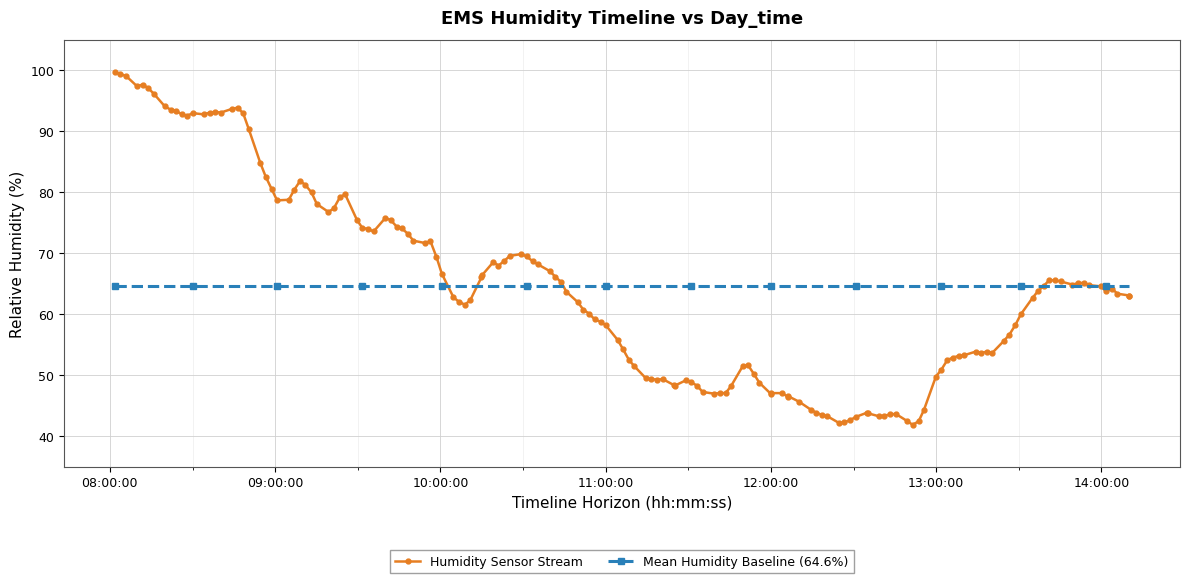

In [2]:
# Line graph styled like the reference figure
mean_humidity = df["Humidity"].mean()

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")

# Humidity stream (orange solid + circular markers)
ax.plot(
    df["Day_time"],
    df["Humidity"],
    color="#e67e22",
    linewidth=1.8,
    marker="o",
    markersize=3.5,
    markerfacecolor="#e67e22",
    markeredgecolor="#e67e22",
    label="Humidity Sensor Stream",
)

# Mean humidity baseline (blue dashed + square markers)
ax.plot(
    df["Day_time"],
    [mean_humidity] * len(df),
    color="#2980b9",
    linewidth=2.2,
    linestyle="--",
    marker="s",
    markersize=4,
    markevery=max(len(df) // 12, 1),
    label=f"Mean Humidity Baseline ({mean_humidity:.1f}%)",
)

# Title & axis labels
ax.set_title(
    "EMS Humidity Timeline vs Day_time",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Timeline Horizon (hh:mm:ss)", fontsize=11)
ax.set_ylabel("Relative Humidity (%)", fontsize=11)

# Axis formatting
ax.set_ylim(35, 105)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.tick_params(axis="both", labelsize=9)

# Light grid like reference
ax.grid(True, which="major", linestyle="-", linewidth=0.6, color="#d0d0d0")
ax.grid(True, which="minor", linestyle="-", linewidth=0.4, color="#e8e8e8")

for spine in ax.spines.values():
    spine.set_color("#555555")

# Legend below plot (reference style)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor="#888888",
    fontsize=9,
)

plt.tight_layout()
plt.show()


Rows: 559
Time range: 2025-08-12 05:54:51 → 2025-08-12 16:59:14
Mean Temp: 37.9°C


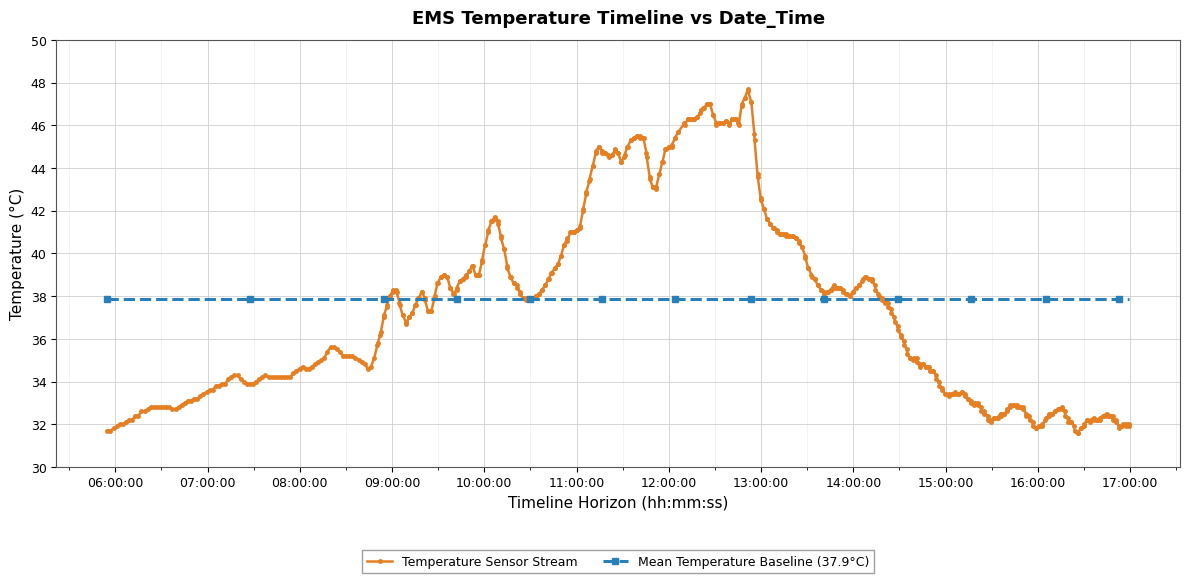

In [3]:
# Load EMS temperature data and plot Date_Time vs Temp (same style)
temp_path = Path(r"Excel file and expected graph form/EMS_Temp/ems_data_time_temp_12_08_2025_0554_1700.xlsx")
df_temp = pd.read_excel(temp_path)

df_temp["Date_Time"] = pd.to_datetime(df_temp["Date_Time"])
df_temp = df_temp.sort_values("Date_Time").reset_index(drop=True)

mean_temp = df_temp["Temp"].mean()
print(f"Rows: {len(df_temp)}")
print(f"Time range: {df_temp['Date_Time'].min()} → {df_temp['Date_Time'].max()}")
print(f"Mean Temp: {mean_temp:.1f}°C")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")

# Temperature stream (orange solid + circular markers)
ax.plot(
    df_temp["Date_Time"],
    df_temp["Temp"],
    color="#e67e22",
    linewidth=1.8,
    marker="o",
    markersize=2.5,
    markerfacecolor="#e67e22",
    markeredgecolor="#e67e22",
    label="Temperature Sensor Stream",
)

# Mean temperature baseline (blue dashed + square markers)
ax.plot(
    df_temp["Date_Time"],
    [mean_temp] * len(df_temp),
    color="#2980b9",
    linewidth=2.2,
    linestyle="--",
    marker="s",
    markersize=4,
    markevery=max(len(df_temp) // 12, 1),
    label=f"Mean Temperature Baseline ({mean_temp:.1f}°C)",
)

# Title & axis labels
ax.set_title(
    "EMS Temperature Timeline vs Date_Time",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Timeline Horizon (hh:mm:ss)", fontsize=11)
ax.set_ylabel("Temperature (°C)", fontsize=11)

# Axis formatting
ax.set_ylim(30, 50)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.tick_params(axis="both", labelsize=9)

# Light grid like reference
ax.grid(True, which="major", linestyle="-", linewidth=0.6, color="#d0d0d0")
ax.grid(True, which="minor", linestyle="-", linewidth=0.4, color="#e8e8e8")

for spine in ax.spines.values():
    spine.set_color("#555555")

# Legend below plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor="#888888",
    fontsize=9,
)

plt.tight_layout()
plt.show()


Rows: 1314
Time range: 2025-07-08 15:03:02.936000 → 2025-07-09 02:08:07.159000
Mean TDS Rolling Mean: 796.2 ppm


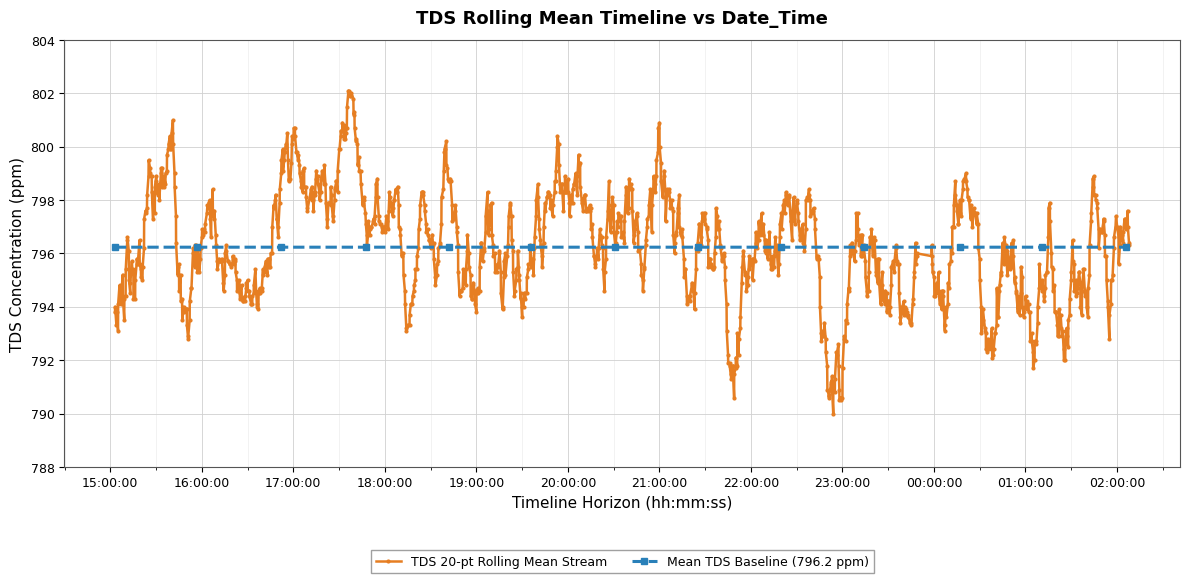

In [4]:
# Load TDS rolling-mean data and plot TDS_Rolling_Mean vs Date_Time (same style)
tds_path = Path(r"Excel file and expected graph form/TDS/TDS_20pt_rolling_mean_08_07_2025.xlsx")
df_tds = pd.read_excel(tds_path)

df_tds["Date_Time"] = pd.to_datetime(df_tds["Date_Time"])
df_tds = df_tds.sort_values("Date_Time").reset_index(drop=True)

mean_tds = df_tds["TDS_Rolling_Mean"].mean()
print(f"Rows: {len(df_tds)}")
print(f"Time range: {df_tds['Date_Time'].min()} → {df_tds['Date_Time'].max()}")
print(f"Mean TDS Rolling Mean: {mean_tds:.1f} ppm")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")

# TDS rolling mean stream (orange solid + circular markers)
ax.plot(
    df_tds["Date_Time"],
    df_tds["TDS_Rolling_Mean"],
    color="#e67e22",
    linewidth=1.8,
    marker="o",
    markersize=2,
    markerfacecolor="#e67e22",
    markeredgecolor="#e67e22",
    label="TDS 20-pt Rolling Mean Stream",
)

# Mean TDS baseline (blue dashed + square markers)
ax.plot(
    df_tds["Date_Time"],
    [mean_tds] * len(df_tds),
    color="#2980b9",
    linewidth=2.2,
    linestyle="--",
    marker="s",
    markersize=4,
    markevery=max(len(df_tds) // 12, 1),
    label=f"Mean TDS Baseline ({mean_tds:.1f} ppm)",
)

# Title & axis labels
ax.set_title(
    "TDS Rolling Mean Timeline vs Date_Time",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Timeline Horizon (hh:mm:ss)", fontsize=11)
ax.set_ylabel("TDS Concentration (ppm)", fontsize=11)

# Axis formatting
ax.set_ylim(788, 804)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.tick_params(axis="both", labelsize=9)

# Light grid like reference
ax.grid(True, which="major", linestyle="-", linewidth=0.6, color="#d0d0d0")
ax.grid(True, which="minor", linestyle="-", linewidth=0.4, color="#e8e8e8")

for spine in ax.spines.values():
    spine.set_color("#555555")

# Legend below plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor="#888888",
    fontsize=9,
)

plt.tight_layout()
plt.show()


Rows: 5086
Time range: 2025-08-12 00:01:46.868000 → 2025-08-12 16:42:42.978000
Mean Nutrient Temp Rolling Mean: 28.48°C


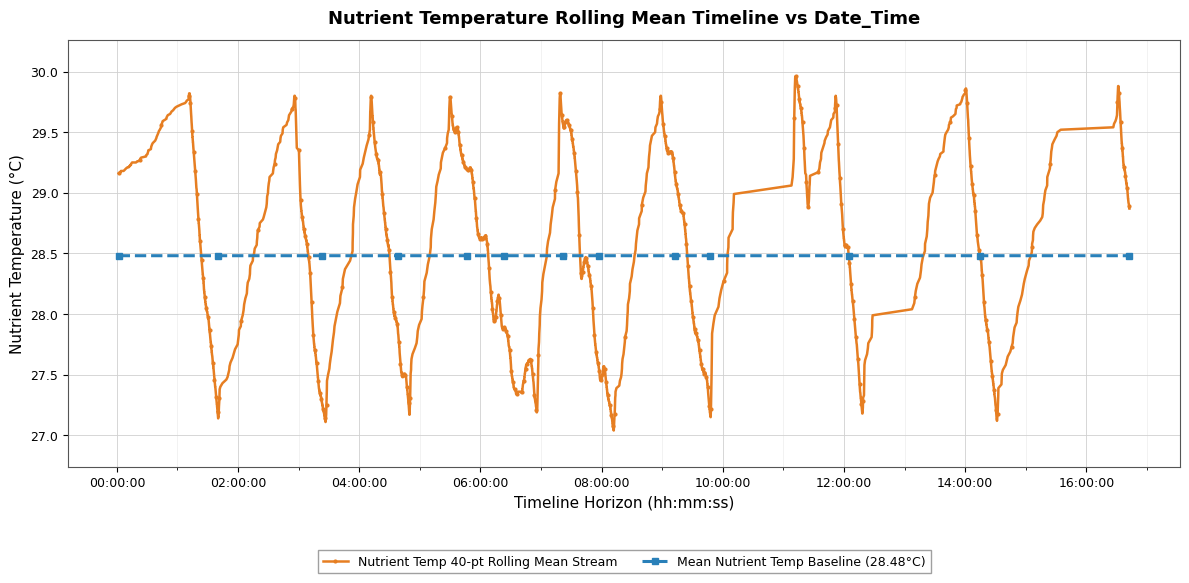

In [5]:
# Load water temperature rolling-mean data and plot Water_Temp_Rolling_Mean_40 vs Date_Time (same style)
wt_path = Path(r"Excel file and expected graph form/Water Temperature/Water_Temperature_40pt_rolling_mean_12_08_2025.xlsx")
df_wt = pd.read_excel(wt_path)

df_wt["Date_Time"] = pd.to_datetime(df_wt["Date_Time"])
df_wt = df_wt.sort_values("Date_Time").reset_index(drop=True)

mean_wt = df_wt["Water_Temp_Rolling_Mean_40"].mean()
print(f"Rows: {len(df_wt)}")
print(f"Time range: {df_wt['Date_Time'].min()} → {df_wt['Date_Time'].max()}")
print(f"Mean Nutrient Temp Rolling Mean: {mean_wt:.2f}°C")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")

# Nutrient temp rolling mean stream (orange solid + circular markers)
ax.plot(
    df_wt["Date_Time"],
    df_wt["Water_Temp_Rolling_Mean_40"],
    color="#e67e22",
    linewidth=1.8,
    marker="o",
    markersize=2,
    markevery=max(len(df_wt) // 250, 1),
    markerfacecolor="#e67e22",
    markeredgecolor="#e67e22",
    label="Nutrient Temp 40-pt Rolling Mean Stream",
)

# Mean nutrient temp baseline (blue dashed + square markers)
ax.plot(
    df_wt["Date_Time"],
    [mean_wt] * len(df_wt),
    color="#2980b9",
    linewidth=2.2,
    linestyle="--",
    marker="s",
    markersize=4,
    markevery=max(len(df_wt) // 12, 1),
    label=f"Mean Nutrient Temp Baseline ({mean_wt:.2f}°C)",
)

# Title & axis labels
ax.set_title(
    "Nutrient Temperature Rolling Mean Timeline vs Date_Time",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Timeline Horizon (hh:mm:ss)", fontsize=11)
ax.set_ylabel("Nutrient Temperature (°C)", fontsize=11)

# Axis formatting
ax.set_ylim(
    df_wt["Water_Temp_Rolling_Mean_40"].min() - 0.3,
    df_wt["Water_Temp_Rolling_Mean_40"].max() + 0.3,
)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.tick_params(axis="both", labelsize=9)

# Light grid like reference
ax.grid(True, which="major", linestyle="-", linewidth=0.6, color="#d0d0d0")
ax.grid(True, which="minor", linestyle="-", linewidth=0.4, color="#e8e8e8")

for spine in ax.spines.values():
    spine.set_color("#555555")

# Legend below plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor="#888888",
    fontsize=9,
)

plt.tight_layout()
plt.show()
